In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
file_path = "home_insurance_cleaned.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Dataset loaded successfully.
Rows: 190006
Columns: 42


,QUOTE_DATE,COVER_START,CLAIM3YEARS,P1_EMP_STATUS,AD_BUILDINGS,RISK_RATED_AREA_B,SUM_INSURED_BUILDINGS,NCD_GRANTED_YEARS_B,AD_CONTENTS,RISK_RATED_AREA_C,SUM_INSURED_CONTENTS,NCD_GRANTED_YEARS_C,CONTENTS_COVER,BUILDINGS_COVER,SPEC_SUM_INSURED,SPEC_ITEM_PREM,P1_DOB,P1_MAR_STATUS,P1_POLICY_REFUSED,P1_SEX,APPR_ALARM,APPR_LOCKS,BEDROOMS,ROOF_CONSTRUCTION,WALL_CONSTRUCTION,FLOODING,LISTED,MAX_DAYS_UNOCC,NEIGH_WATCH,OCC_STATUS,OWNERSHIP_TYPE,PROP_TYPE,SAFE_INSTALLED,SEC_DISC_REQ,SUBSIDENCE,YEARBUILT,PAYMENT_METHOD,LAST_ANN_PREM_GROSS,POL_STATUS,AGE_AT_QUOTE,QUOTE_YEAR,QUOTE_MONTH
0,22-11-2007,22-11-2007,N,R,Y,19.0,1000000.0,7.0,Y,6.0,50000.0,7.0,Y,Y,7500.0,44.42,15-06-1939,O,N,M,N,Y,3.0,11.0,15.0,Y,3.0,0.0,N,PH,8.0,10.0,Y,Y,N,1960.0,PureDD,274.81,Lapsed,68.438056,2007.0,11.0
1,22-11-2007,01-01-2008,N,E,Y,25.0,1000000.0,6.0,Y,9.0,50000.0,7.0,Y,Y,0.0,0.00,20-05-1970,M,N,M,N,N,3.0,11.0,15.0,Y,3.0,0.0,N,PH,3.0,2.0,N,N,N,1960.0,PureDD,308.83,Live,37.508556,2007.0,11.0
2,23-11-2007,23-11-2007,N,E,N,NaN,0.0,0.0,Y,12.0,50000.0,7.0,N,Y,0.0,0.00,10-06-1947,S,N,M,Y,Y,2.0,11.0,15.0,Y,3.0,0.0,Y,PH,8.0,9.0,N,Y,N,1946.0,PureDD,52.65,Live,60.454483,2007.0,11.0
3,23-11-2007,12-12-2007,N,R,N,NaN,0.0,0.0,Y,14.0,50000.0,7.0,N,Y,0.0,0.00,16-12-1925,W,N,F,N,Y,2.0,11.0,15.0,Y,3.0,0.0,N,PH,18.0,19.0,N,Y,N,1870.0,NonDD,54.23,Live,81.935661,2007.0,11.0
4,22-11-2007,15-12-2007,N,R,Y,5.0,1000000.0,7.0,Y,10.0,50000.0,7.0,Y,Y,0.0,0.00,11-02-1936,M,N,M,Y,Y,3.0,11.0,15.0,Y,3.0,0.0,N,PH,8.0,1.0,N,Y,N,1960.0,DD-Other,244.58,Live,71.778234,2007.0,11.0


In [4]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (190006, 42)

Column names:
['QUOTE_DATE', 'COVER_START', 'CLAIM3YEARS', 'P1_EMP_STATUS', 'AD_BUILDINGS', 'RISK_RATED_AREA_B', 'SUM_INSURED_BUILDINGS', 'NCD_GRANTED_YEARS_B', 'AD_CONTENTS', 'RISK_RATED_AREA_C', 'SUM_INSURED_CONTENTS', 'NCD_GRANTED_YEARS_C', 'CONTENTS_COVER', 'BUILDINGS_COVER', 'SPEC_SUM_INSURED', 'SPEC_ITEM_PREM', 'P1_DOB', 'P1_MAR_STATUS', 'P1_POLICY_REFUSED', 'P1_SEX', 'APPR_ALARM', 'APPR_LOCKS', 'BEDROOMS', 'ROOF_CONSTRUCTION', 'WALL_CONSTRUCTION', 'FLOODING', 'LISTED', 'MAX_DAYS_UNOCC', 'NEIGH_WATCH', 'OCC_STATUS', 'OWNERSHIP_TYPE', 'PROP_TYPE', 'SAFE_INSTALLED', 'SEC_DISC_REQ', 'SUBSIDENCE', 'YEARBUILT', 'PAYMENT_METHOD', 'LAST_ANN_PREM_GROSS', 'POL_STATUS', 'AGE_AT_QUOTE', 'QUOTE_YEAR', 'QUOTE_MONTH']

Data types:


,dtype
QUOTE_DATE,object
COVER_START,object
CLAIM3YEARS,object
P1_EMP_STATUS,object
AD_BUILDINGS,object
RISK_RATED_AREA_B,float64
SUM_INSURED_BUILDINGS,float64
NCD_GRANTED_YEARS_B,float64
AD_CONTENTS,object
RISK_RATED_AREA_C,float64



Duplicate rows: 21


In [5]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_percent", ascending=False)
display(missing[missing["missing_count"] > 0])

,missing_count,missing_percent
AGE_AT_QUOTE,144435,76.02
QUOTE_DATE,144090,75.83
QUOTE_YEAR,144090,75.83
QUOTE_MONTH,144090,75.83
RISK_RATED_AREA_B,49133,25.86
RISK_RATED_AREA_C,9747,5.13
AD_BUILDINGS,1017,0.54
PROP_TYPE,1017,0.54
FLOODING,1017,0.54
LISTED,1017,0.54


In [7]:
data = df.copy()
data = data.drop(columns=["i", "Police"], errors="ignore")
data = data.drop(columns=["PAYMENT_FREQUENCY"], errors="ignore")
data = data.dropna(subset=["LAST_ANN_PREM_GROSS"]).copy()
data = data[data["LAST_ANN_PREM_GROSS"] >= 0].copy()
print("Rows after removing missing/invalid target:", len(data))
print("Columns after basic cleaning:", len(data.columns))

Rows after removing missing/invalid target: 190006
Columns after basic cleaning: 42


In [9]:
data["QUOTE_DATE"] = pd.to_datetime(data["QUOTE_DATE"], errors="coerce")
data["COVER_START"] = pd.to_datetime(data["COVER_START"], errors="coerce", dayfirst=True)
data["P1_DOB"] = pd.to_datetime(data["P1_DOB"], errors="coerce", dayfirst=True)
data["AGE_AT_QUOTE"] = (
    (data["QUOTE_DATE"] - data["P1_DOB"]).dt.days / 365.25
)
data.loc[(data["AGE_AT_QUOTE"] < 18) | (data["AGE_AT_QUOTE"] > 100), "AGE_AT_QUOTE"] = np.nan
data["QUOTE_YEAR"] = data["QUOTE_DATE"].dt.year
data["QUOTE_MONTH"] = data["QUOTE_DATE"].dt.month
display(data[["QUOTE_DATE", "P1_DOB", "AGE_AT_QUOTE", "QUOTE_YEAR", "QUOTE_MONTH"]].head())

,QUOTE_DATE,P1_DOB,AGE_AT_QUOTE,QUOTE_YEAR,QUOTE_MONTH
0,2007-11-22,1939-06-15,68.438056,2007.0,11.0
1,2007-11-22,1970-05-20,37.508556,2007.0,11.0
2,2007-11-23,1947-06-10,60.454483,2007.0,11.0
3,2007-11-23,1925-12-16,81.935661,2007.0,11.0
4,2007-11-22,1936-02-11,71.778234,2007.0,11.0


count    190006.000000
mean        186.891196
std          99.413816
min           0.000000
25%         123.620000
50%         177.400000
75%         235.100000
max        4631.860000
Name: LAST_ANN_PREM_GROSS, dtype: float64


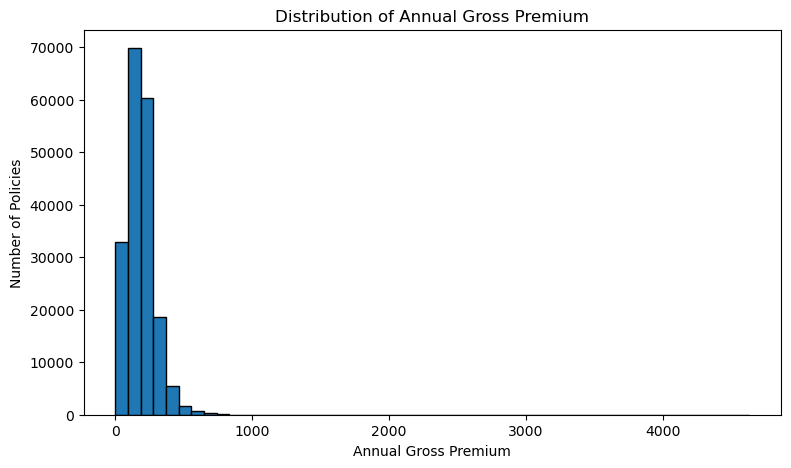

In [10]:
print(data["LAST_ANN_PREM_GROSS"].describe())
plt.figure(figsize=(9, 5))
plt.hist(data["LAST_ANN_PREM_GROSS"], bins=50, edgecolor="black")
plt.title("Distribution of Annual Gross Premium")
plt.xlabel("Annual Gross Premium")
plt.ylabel("Number of Policies")
plt.show()

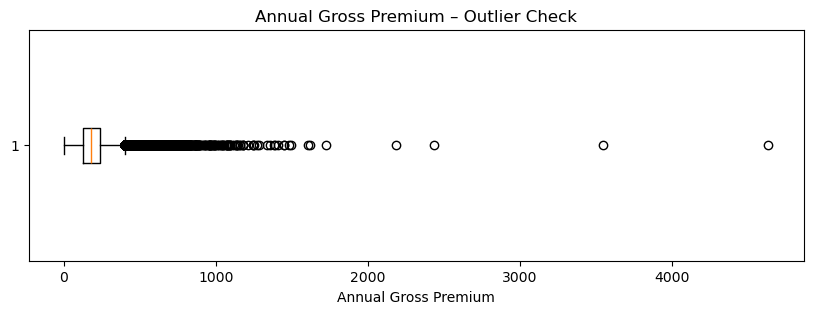

Premium skewness: 2.2


In [11]:
plt.figure(figsize=(10, 3))
plt.boxplot(data["LAST_ANN_PREM_GROSS"], vert=False)
plt.title("Annual Gross Premium – Outlier Check")
plt.xlabel("Annual Gross Premium")
plt.show()
print("Premium skewness:", round(data["LAST_ANN_PREM_GROSS"].skew(), 2))

In [12]:
numeric_cols = data.select_dtypes(include=np.number).columns
corr = data[numeric_cols].corr(numeric_only=True)["LAST_ANN_PREM_GROSS"].sort_values(ascending=False)
display(corr.to_frame("correlation_with_premium"))

,correlation_with_premium
LAST_ANN_PREM_GROSS,1.000000
SUM_INSURED_BUILDINGS,0.573429
BEDROOMS,0.508560
NCD_GRANTED_YEARS_B,0.446805
SPEC_ITEM_PREM,0.231229
SPEC_SUM_INSURED,0.228742
RISK_RATED_AREA_B,0.153445
RISK_RATED_AREA_C,0.071733
SUM_INSURED_CONTENTS,0.065996
WALL_CONSTRUCTION,0.016904


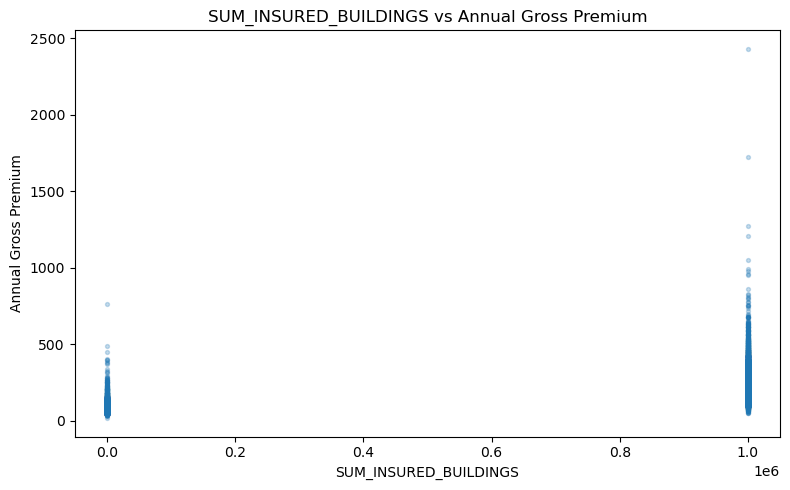

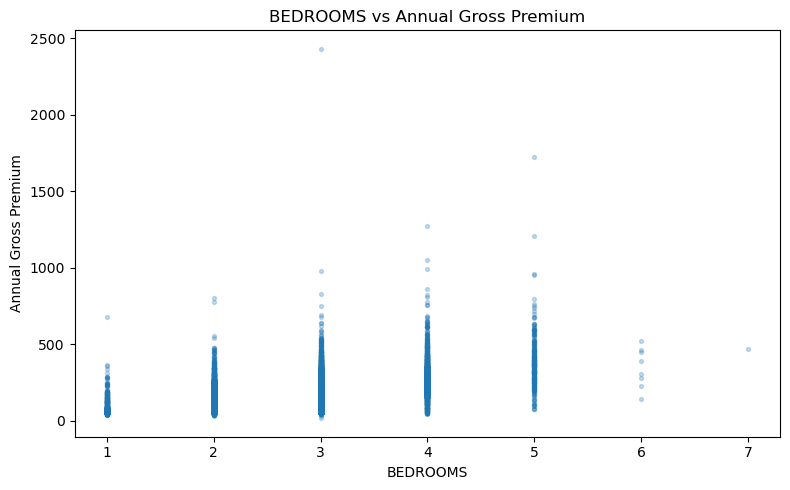

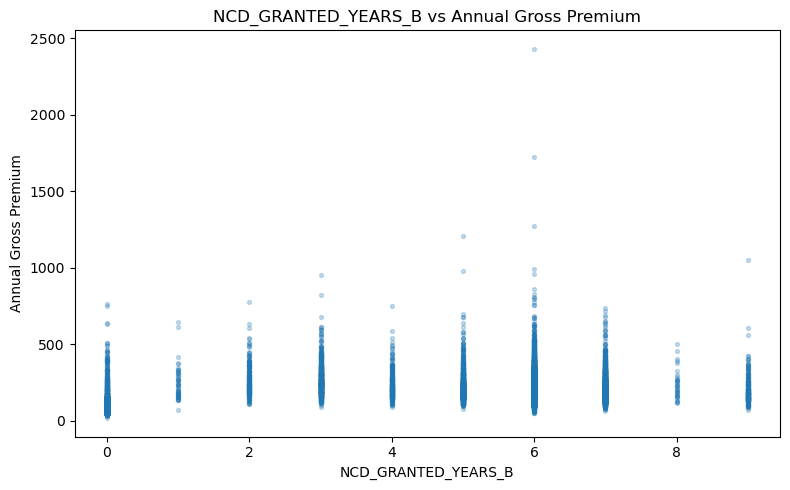

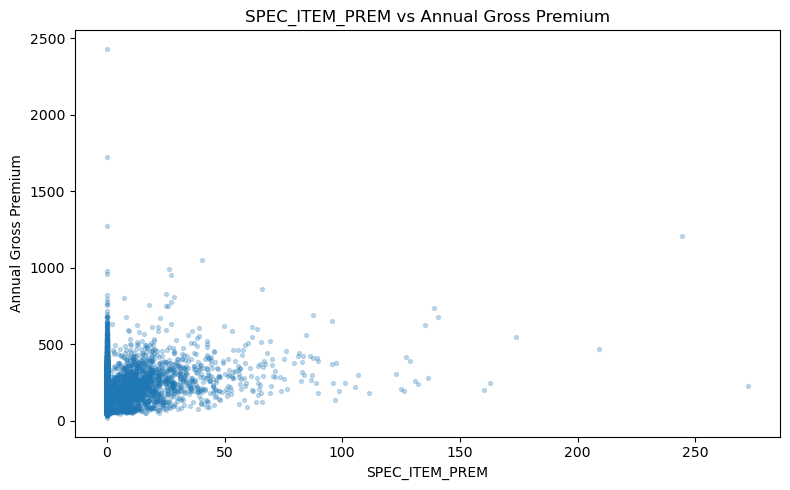

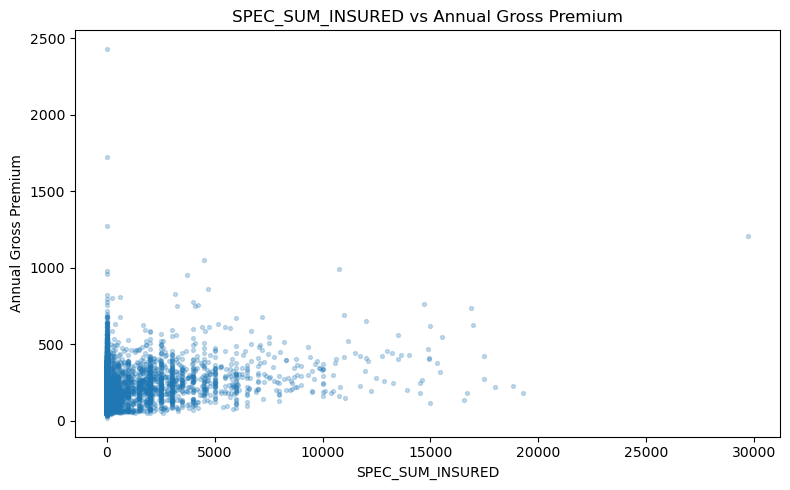

In [13]:
top_numeric = [
    c for c in corr.index
    if c != "LAST_ANN_PREM_GROSS"
    and pd.notna(corr[c])
][:5]

for col in top_numeric:
    plt.figure(figsize=(8, 5))
    sample = data.sample(min(15000, len(data)), random_state=42)
    plt.scatter(sample[col], sample["LAST_ANN_PREM_GROSS"], alpha=0.25, s=8)
    plt.title(f"{col} vs Annual Gross Premium")
    plt.xlabel(col)
    plt.ylabel("Annual Gross Premium")
    plt.tight_layout()
    plt.show()

In [14]:
categorical_cols = data.select_dtypes(include="object").columns.tolist()
categorical_cols = [
    c for c in categorical_cols
    if data[c].nunique(dropna=True) <= 20
]
print("Categorical columns used for group analysis:")
print(categorical_cols)

Categorical columns used for group analysis:
['CLAIM3YEARS', 'P1_EMP_STATUS', 'AD_BUILDINGS', 'AD_CONTENTS', 'CONTENTS_COVER', 'BUILDINGS_COVER', 'P1_MAR_STATUS', 'P1_POLICY_REFUSED', 'P1_SEX', 'APPR_ALARM', 'APPR_LOCKS', 'FLOODING', 'NEIGH_WATCH', 'OCC_STATUS', 'SAFE_INSTALLED', 'SEC_DISC_REQ', 'SUBSIDENCE', 'PAYMENT_METHOD', 'POL_STATUS']


In [15]:
def premium_by_category(df, column, min_count=100):
    result = (
        df.groupby(column, dropna=False)["LAST_ANN_PREM_GROSS"]
        .agg(policy_count="count", mean_premium="mean", median_premium="median")
        .query("policy_count >= @min_count")
        .sort_values("mean_premium", ascending=False)
    )
    return result
selected_categories = [
    "CLAIM3YEARS", "AD_BUILDINGS", "AD_CONTENTS",
    "BUILDINGS_COVER", "CONTENTS_COVER",
    "FLOODING", "APPR_ALARM", "APPR_LOCKS",
    "NEIGH_WATCH", "SAFE_INSTALLED",
    "SEC_DISC_REQ", "SUBSIDENCE", "PAYMENT_METHOD",
    "P1_SEX", "POL_STATUS"
]
for col in selected_categories:
    if col in data.columns:
        print("\n---", col, "---")
        display(premium_by_category(data, col))


--- CLAIM3YEARS ---


,policy_count,mean_premium,median_premium
CLAIM3YEARS,,,
Y,21949,234.478074,220.98
N,168057,180.676135,173.25



--- AD_BUILDINGS ---


,policy_count,mean_premium,median_premium
AD_BUILDINGS,,,
Y,147255,217.258765,198.470
NaN,1017,208.689971,187.930
N,41734,79.210511,63.975



--- AD_CONTENTS ---


...

,policy_count,mean_premium,median_premium
PAYMENT_METHOD,,,
NaN,1017,208.689971,187.93
DD-Other,8333,201.315977,188.20
PureDD,85606,196.583238,185.54
NonDD,95050,176.664283,170.80



--- P1_SEX ---


,policy_count,mean_premium,median_premium
P1_SEX,,,
NaN,1017,208.689971,187.93
M,102978,193.664787,182.33
F,85923,178.410281,171.26



--- POL_STATUS ---


,policy_count,mean_premium,median_premium
POL_STATUS,,,
NaN,1017,208.689971,187.930
Cancelled,4310,202.133780,184.950
Lapsed,52516,196.750644,181.715
Live,132147,182.309050,175.350


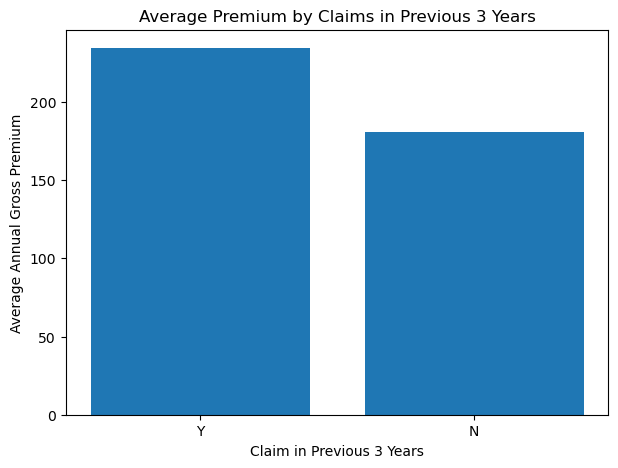

In [16]:
plot_data = premium_by_category(data, "CLAIM3YEARS").reset_index()
plt.figure(figsize=(7, 5))
plt.bar(plot_data["CLAIM3YEARS"].astype(str), plot_data["mean_premium"])
plt.title("Average Premium by Claims in Previous 3 Years")
plt.xlabel("Claim in Previous 3 Years")
plt.ylabel("Average Annual Gross Premium")
plt.show()

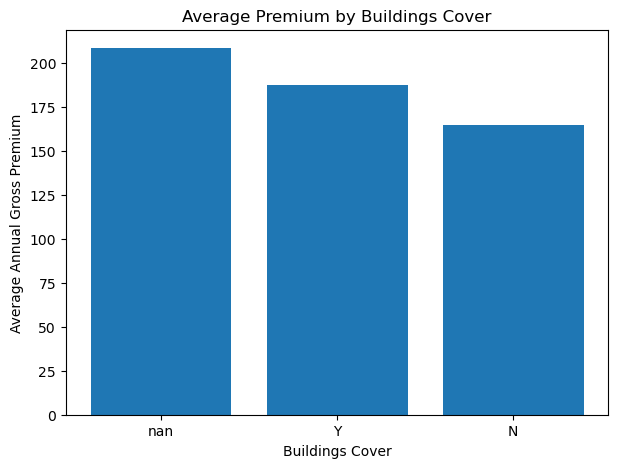

In [17]:
plot_data = premium_by_category(data, "BUILDINGS_COVER").reset_index()
plt.figure(figsize=(7, 5))
plt.bar(plot_data["BUILDINGS_COVER"].astype(str), plot_data["mean_premium"])
plt.title("Average Premium by Buildings Cover")
plt.xlabel("Buildings Cover")
plt.ylabel("Average Annual Gross Premium")
plt.show()

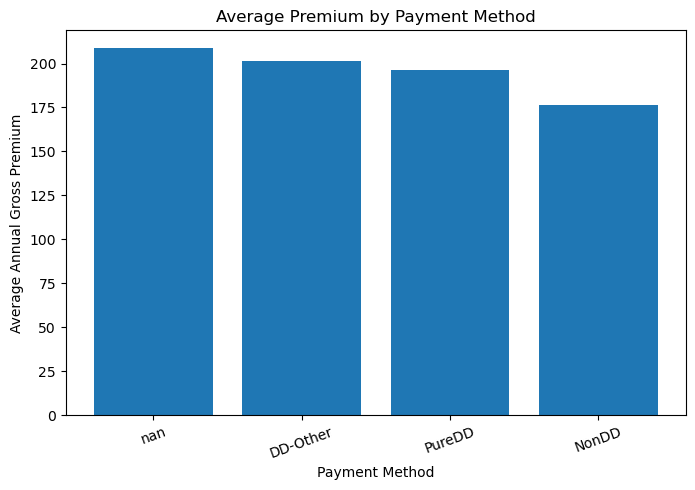

In [18]:
plot_data = premium_by_category(data, "PAYMENT_METHOD").reset_index()
plt.figure(figsize=(8, 5))
plt.bar(plot_data["PAYMENT_METHOD"].astype(str), plot_data["mean_premium"])
plt.title("Average Premium by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Annual Gross Premium")
plt.xticks(rotation=20)
plt.show()

,QUOTE_YEAR,count,mean,median
0,2006.0,6,209.408333,198.015
1,2007.0,3841,176.678912,165.970
2,2008.0,7428,182.804946,175.575
3,2009.0,10057,182.449730,171.950
4,2010.0,15974,171.960344,158.305
5,2011.0,8609,170.036988,158.340
6,2012.0,1,305.070000,305.070


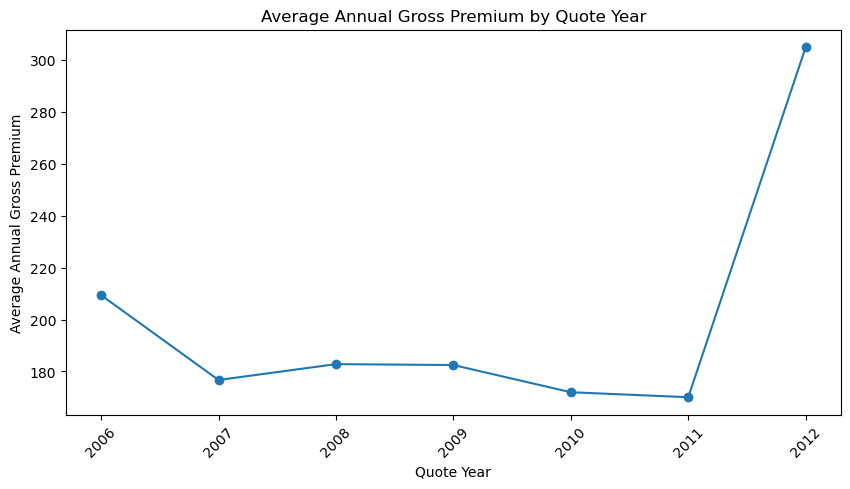

In [19]:
year_data = (
    data.dropna(subset=["QUOTE_YEAR"])
    .groupby("QUOTE_YEAR")["LAST_ANN_PREM_GROSS"]
    .agg(["count", "mean", "median"])
    .reset_index()
)
display(year_data)
plt.figure(figsize=(10, 5))
plt.plot(year_data["QUOTE_YEAR"], year_data["mean"], marker="o")
plt.title("Average Annual Gross Premium by Quote Year")
plt.xlabel("Quote Year")
plt.ylabel("Average Annual Gross Premium")
plt.xticks(rotation=45)
plt.show()

,BEDROOMS,count,mean,median
0,1.0,9801,80.845597,56.650
1,2.0,52955,144.800788,142.900
2,3.0,98843,192.729650,186.420
3,4.0,23992,271.379322,259.555
4,5.0,3263,372.288406,351.070
5,6.0,118,458.993305,427.955
6,7.0,17,474.687647,439.720


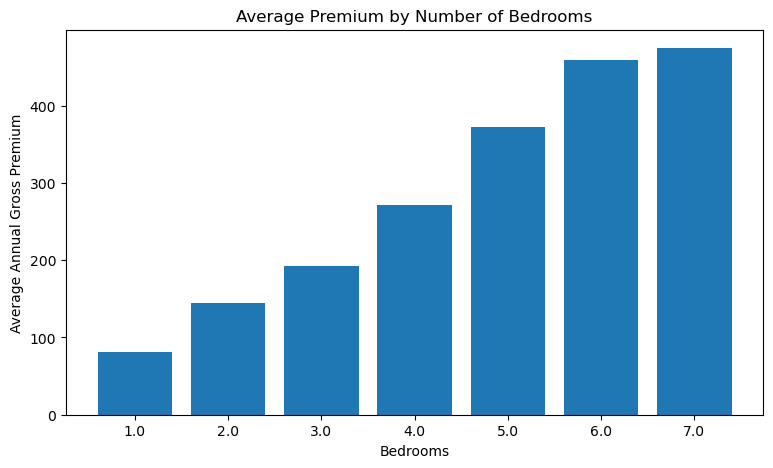

In [20]:
bedroom_data = (
    data.groupby("BEDROOMS")["LAST_ANN_PREM_GROSS"]
    .agg(["count", "mean", "median"])
    .reset_index()
)
display(bedroom_data)
plt.figure(figsize=(9, 5))
plt.bar(bedroom_data["BEDROOMS"].astype(str), bedroom_data["mean"])
plt.title("Average Premium by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Annual Gross Premium")
plt.show()

,SUM_INSURED_BUILDINGS,count,mean,median
0,0.0,41910,80.003104,64.225
1,1000000.0,147079,217.198109,198.420


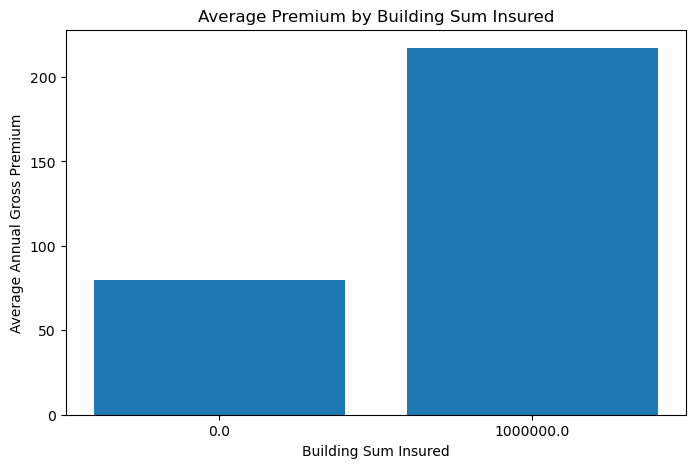

In [21]:
building_data = (
    data.groupby("SUM_INSURED_BUILDINGS")["LAST_ANN_PREM_GROSS"]
    .agg(["count", "mean", "median"])
    .reset_index()
)
display(building_data)
plt.figure(figsize=(8, 5))
plt.bar(building_data["SUM_INSURED_BUILDINGS"].astype(str), building_data["mean"])
plt.title("Average Premium by Building Sum Insured")
plt.xlabel("Building Sum Insured")
plt.ylabel("Average Annual Gross Premium")
plt.show()

In [22]:
model_data = data.copy()
model_data = model_data.drop(
    columns=["QUOTE_DATE", "COVER_START", "P1_DOB"],
    errors="ignore"
)
X = model_data.drop(columns=["LAST_ANN_PREM_GROSS"])
y = model_data["LAST_ANN_PREM_GROSS"]
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 19
Categorical features: 19


In [23]:
sample_size = min(60000, len(X))
sample_idx = X.sample(sample_size, random_state=42).index
X_sample = X.loc[sample_idx]
y_sample = y.loc[sample_idx]
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.20, random_state=42
)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
model = RandomForestRegressor(
    n_estimators=80,
    random_state=42,
    n_jobs=-1,
    max_depth=18,
    min_samples_leaf=3
)
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])
print("Model pipeline created.")

Model pipeline created.


In [24]:
pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")

MAE  : 34.68
RMSE : 52.28
R²   : 0.723


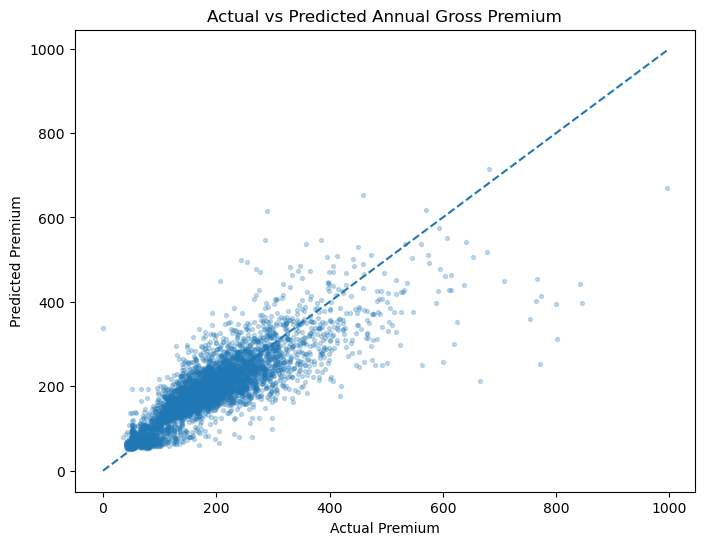

In [25]:
pred_plot = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": pred
}).sample(min(5000, len(y_test)), random_state=42)
plt.figure(figsize=(8, 6))
plt.scatter(pred_plot["Actual"], pred_plot["Predicted"], alpha=0.25, s=8)
plt.title("Actual vs Predicted Annual Gross Premium")
plt.xlabel("Actual Premium")
plt.ylabel("Predicted Premium")
max_val = max(pred_plot["Actual"].max(), pred_plot["Predicted"].max())
plt.plot([0, max_val], [0, max_val], linestyle="--")
plt.show()

,feature,importance
36,cat__CONTENTS_COVER_N,0.192195
32,cat__AD_BUILDINGS_N,0.173665
8,num__BEDROOMS,0.155689
15,num__YEARBUILT,0.093213
7,num__SPEC_ITEM_PREM,0.057305
0,num__RISK_RATED_AREA_B,0.052969
3,num__RISK_RATED_AREA_C,0.033181
14,num__PROP_TYPE,0.026669
2,num__NCD_GRANTED_YEARS_B,0.019885
12,num__MAX_DAYS_UNOCC,0.017648


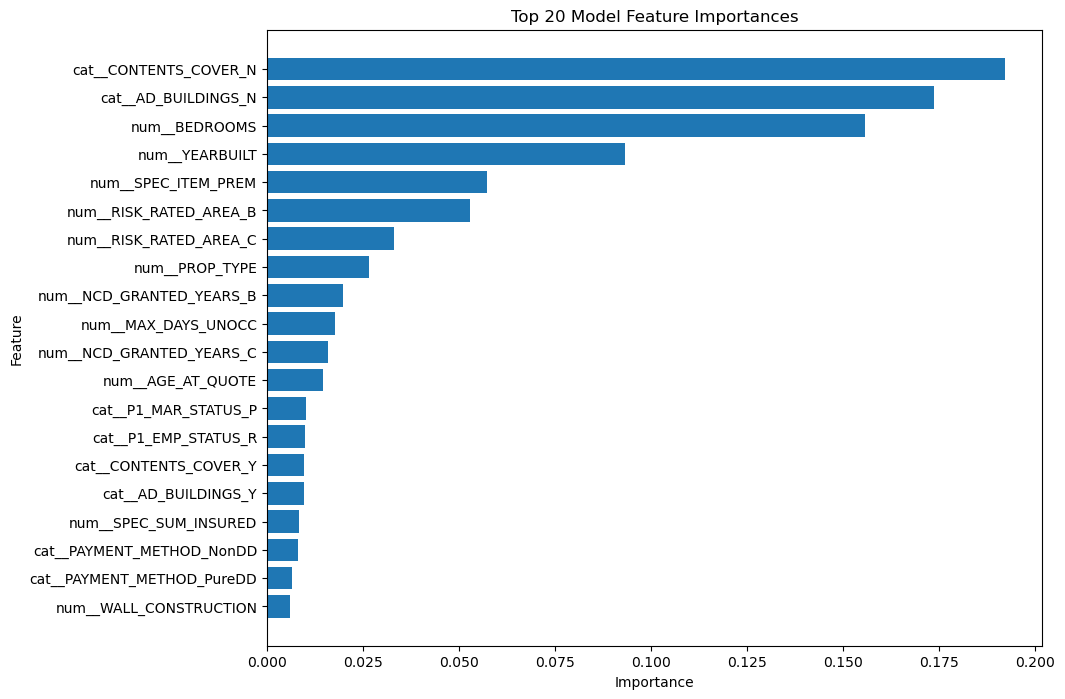

In [29]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_
feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)
top_features = feature_importance.head(20)
display(top_features)
plt.figure(figsize=(10, 8))
sorted_features = top_features.sort_values("importance")
plt.barh(sorted_features["feature"], sorted_features["importance"])
plt.title("Top 20 Model Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [28]:
numeric_summary = (
    corr.drop("LAST_ANN_PREM_GROSS", errors="ignore")
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
numeric_summary.columns = ["attribute", "absolute_correlation"]
print("Top numeric attributes by absolute correlation:")
display(numeric_summary)
cat_results = []
for col in selected_categories:
    if col in data.columns:
        temp = premium_by_category(data, col, min_count=100)
        if len(temp) >= 2:
            premium_range = temp["mean_premium"].max() - temp["mean_premium"].min()
            cat_results.append({
                "attribute": col,
                "highest_group_mean": temp["mean_premium"].max(),
                "lowest_group_mean": temp["mean_premium"].min(),
                "premium_difference": premium_range
            })
cat_summary = pd.DataFrame(cat_results).sort_values(
    "premium_difference", ascending=False
)
print("Categorical attributes with largest mean-premium differences:")
display(cat_summary)

Top numeric attributes by absolute correlation:


,attribute,absolute_correlation
0,SUM_INSURED_BUILDINGS,0.573429
1,BEDROOMS,0.508560
2,NCD_GRANTED_YEARS_B,0.446805
3,OWNERSHIP_TYPE,0.274556
4,PROP_TYPE,0.259850
5,YEARBUILT,0.251420
6,SPEC_ITEM_PREM,0.231229
7,SPEC_SUM_INSURED,0.228742
8,AGE_AT_QUOTE,0.182211
9,RISK_RATED_AREA_B,0.153445


Categorical attributes with largest mean-premium differences:


,attribute,highest_group_mean,lowest_group_mean,premium_difference
1,AD_BUILDINGS,217.258765,79.210511,138.048254
4,CONTENTS_COVER,217.258765,79.210511,138.048254
9,SAFE_INSTALLED,298.716202,185.817481,112.898721
0,CLAIM3YEARS,234.478074,180.676135,53.801938
11,SUBSIDENCE,208.689971,164.206683,44.483288
2,AD_CONTENTS,208.689971,164.753454,43.936517
3,BUILDINGS_COVER,208.689971,164.753454,43.936517
6,APPR_ALARM,223.543523,183.810792,39.732732
10,SEC_DISC_REQ,208.689971,174.004688,34.685283
12,PAYMENT_METHOD,208.689971,176.664283,32.025688
